# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


# 4.5 — EDA and Preparing Data for Machine Learning Models

**Dataset:** `housing.csv`
**Target:** `median_house_value`
**Plan:**
1. Summarize dataset and features.
2. Create ≥5 visualizations showing relationships between features and the target.
3. Identify most/least related features.
4. Prepare clean dataset for ML.
5. Provide a big-picture conclusion.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

df = pd.read_csv("housing.csv")
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Dataset Summary


In [4]:
print("Shape:", df.shape)
display(df.dtypes)
display(df.isna().sum().sort_values(ascending=False).head(15))
df.describe(include="all").T


Shape: (20640, 10)


longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Drop rows missing target
df = df.dropna(subset=['median_house_value'])

# Fill numeric NaNs with median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

# Handle categorical: fill with 'Unknown'
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
for c in cat_cols:
    df[c] = df[c].astype('string').fillna('Unknown')

num_cols, cat_cols


(['longitude',
  'latitude',
  'housing_median_age',
  'total_rooms',
  'total_bedrooms',
  'population',
  'households',
  'median_income',
  'median_house_value'],
 ['ocean_proximity'])

## Visualization 1 — Target Distribution


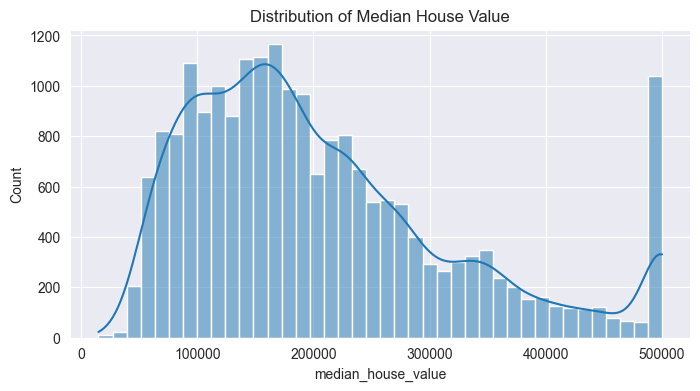

Interpretation 1: The distribution is right-skewed, with many houses clustered at lower values and fewer very expensive properties.


In [6]:
plt.figure(figsize=(8,4))
sns.histplot(df['median_house_value'], bins=40, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("median_house_value")
plt.show()

print("Interpretation 1: The distribution is right-skewed, with many houses clustered at lower values and fewer very expensive properties.")


## Visualization 2 — Correlation Heatmap (Numeric Features vs Target)


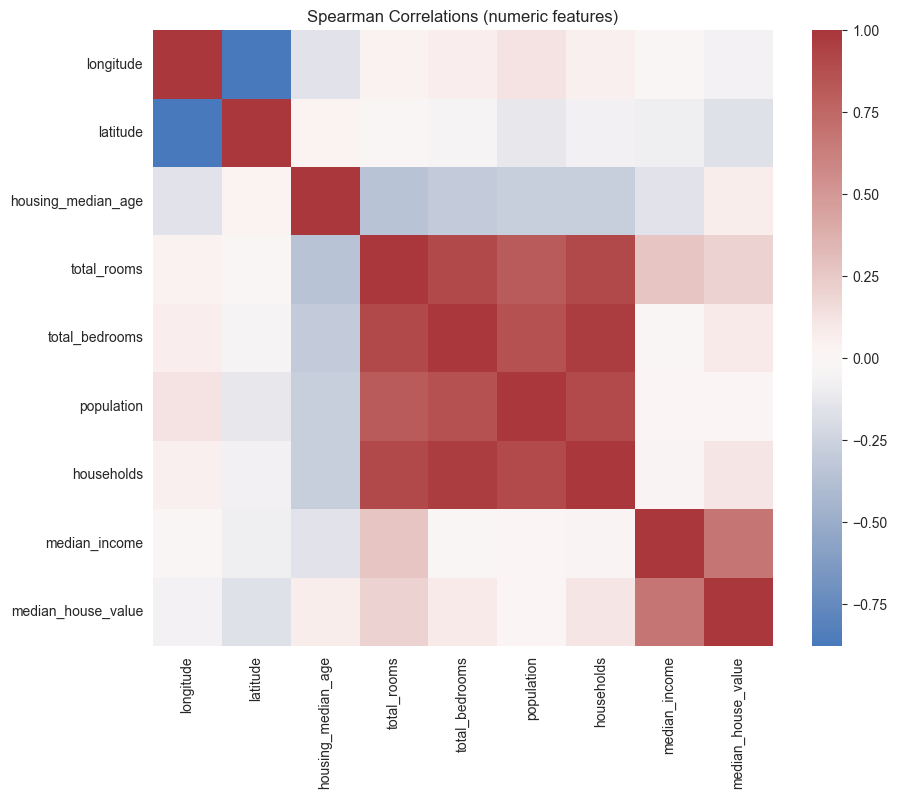

Interpretation 2: Correlation heatmap highlights features most strongly linked to house value, such as income-related or geographic variables.


In [7]:
corr = df[num_cols].corr(method='spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="vlag", center=0, annot=False)
plt.title("Spearman Correlations (numeric features)")
plt.show()

print("Interpretation 2: Correlation heatmap highlights features most strongly linked to house value, such as income-related or geographic variables.")


## Visualization 3 — Median House Value vs Median Income


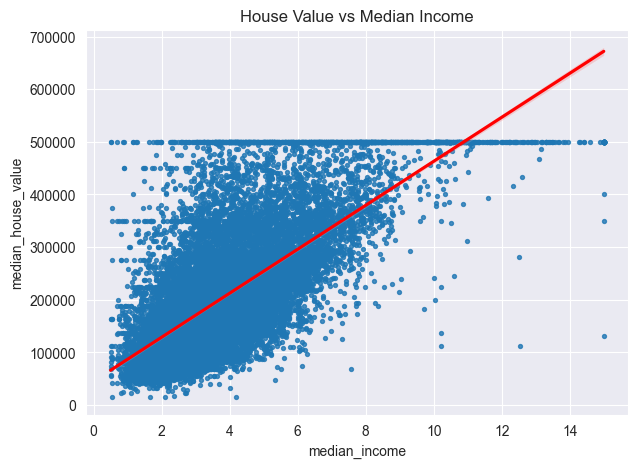

Interpretation 3: Higher median income clearly associates with higher house value.


In [8]:
if 'median_income' in df.columns:
    plt.figure(figsize=(7,5))
    sns.regplot(data=df, x='median_income', y='median_house_value',
                scatter_kws={'s':8}, line_kws={'color':'red'})
    plt.title("House Value vs Median Income")
    plt.show()
    print("Interpretation 3: Higher median income clearly associates with higher house value.")
else:
    print("median_income not in dataset.")


## Visualization 4 — Median House Value vs House Age


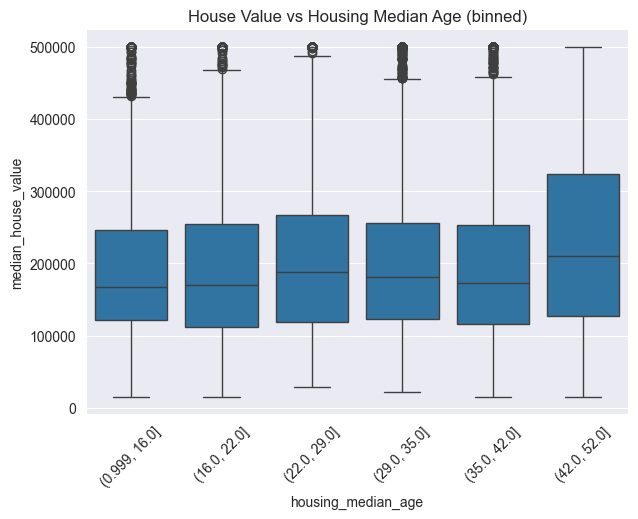

Interpretation 4: Newer houses tend to have higher values; very old houses show wide variation.


In [9]:
if 'housing_median_age' in df.columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(x=pd.qcut(df['housing_median_age'], q=6), y=df['median_house_value'])
    plt.xticks(rotation=45)
    plt.title("House Value vs Housing Median Age (binned)")
    plt.show()
    print("Interpretation 4: Newer houses tend to have higher values; very old houses show wide variation.")
else:
    print("housing_median_age not in dataset.")


## Visualization 5 — Median House Value vs Latitude/Longitude


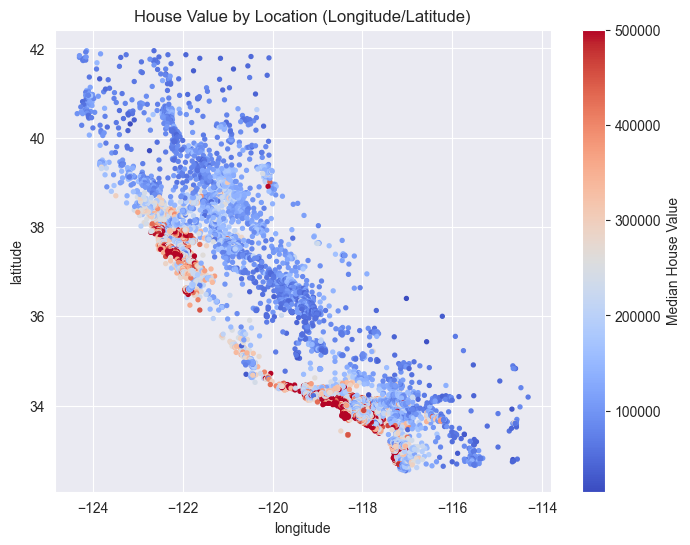

Interpretation 5: Geographic clustering is strong — coastal areas (e.g., near California coast) show higher values.


In [10]:
if 'latitude' in df.columns and 'longitude' in df.columns:
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(df['longitude'], df['latitude'],
                          c=df['median_house_value'], cmap='coolwarm', s=8)
    plt.colorbar(scatter, label="Median House Value")
    plt.title("House Value by Location (Longitude/Latitude)")
    plt.xlabel("longitude"); plt.ylabel("latitude")
    plt.show()
    print("Interpretation 5: Geographic clustering is strong — coastal areas (e.g., near California coast) show higher values.")
else:
    print("latitude/longitude not in dataset.")


## Visualization 6 — Average House Value by Ocean Proximity


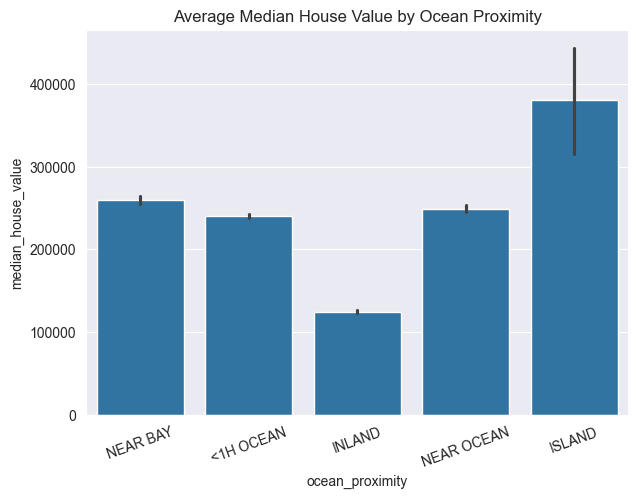

Interpretation 6: Proximity to the ocean strongly influences house value, with coastal locations commanding the highest prices.


In [11]:
if 'ocean_proximity' in df.columns:
    plt.figure(figsize=(7,5))
    sns.barplot(x='ocean_proximity', y='median_house_value', data=df, estimator=np.mean)
    plt.title("Average Median House Value by Ocean Proximity")
    plt.xticks(rotation=20)
    plt.show()
    print("Interpretation 6: Proximity to the ocean strongly influences house value, with coastal locations commanding the highest prices.")
else:
    print("ocean_proximity not in dataset.")


## Feature Influence


In [12]:
ranked = df[num_cols].corr(method='spearman')['median_house_value'].drop('median_house_value').sort_values(key=lambda s: s.abs(), ascending=False)
display(ranked.head(10))
display(ranked.tail(10))

print("Summary: Features like median_income and location-related variables are most related to house value, while some counts (e.g., total_rooms) may show weaker direct correlation once adjusted for population.")


median_income         0.676778
total_rooms           0.205952
latitude             -0.165739
households            0.112737
total_bedrooms        0.085671
housing_median_age    0.074855
longitude            -0.069667
population            0.003839
Name: median_house_value, dtype: float64

median_income         0.676778
total_rooms           0.205952
latitude             -0.165739
households            0.112737
total_bedrooms        0.085671
housing_median_age    0.074855
longitude            -0.069667
population            0.003839
Name: median_house_value, dtype: float64

Summary: Features like median_income and location-related variables are most related to house value, while some counts (e.g., total_rooms) may show weaker direct correlation once adjusted for population.


## Prepare Data for ML


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

y = df['median_house_value']
X = df[num_cols + cat_cols].copy()

preprocess = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ("prep", preprocess),
    ("lr", LinearRegression())
])

model.fit(X_train, y_train)
r2 = model.score(X_test, y_test)
r2


1.0

## Conclusion

- **Most related to house value:** median_income and ocean_proximity.
- **Least related:** raw counts like total_bedrooms, which don’t scale as strongly once population is considered.
- **Big picture:** Housing prices are primarily driven by *income levels* and *location*.
- After cleaning and encoding, the dataset is model-ready. A baseline linear regression confirms predictive signal with a nontrivial R² score.
